In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
dataset = datasets.ImageFolder("../../../task 2 - Image segmentation/U-Net++/EMDS5-Unetpp-DnCnn", transform=transform)
class_names = dataset.classes

train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)


In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=len(class_names)).to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

metric_acc = Accuracy(task='multiclass', num_classes=len(class_names)).to(device)
metric_precision = Precision(task='multiclass', num_classes=len(class_names)).to(device)
metric_recall = Recall(task='multiclass', num_classes=len(class_names)).to(device)
metric_f1 = F1Score(task='multiclass', num_classes=len(class_names)).to(device)


Epoch 1/30 | Train Loss: 3.2125 | Val Loss: 2.6458
Val Accuracy: 0.2619, Precision: 0.2619, Recall: 0.2619, F1: 0.2619
Best model saved!
Epoch 2/30 | Train Loss: 1.5732 | Val Loss: 1.8942
Val Accuracy: 0.4405, Precision: 0.4405, Recall: 0.4405, F1: 0.4405
Best model saved!
Epoch 3/30 | Train Loss: 0.9417 | Val Loss: 1.4781
Val Accuracy: 0.5595, Precision: 0.5595, Recall: 0.5595, F1: 0.5595
Best model saved!
Epoch 4/30 | Train Loss: 0.6089 | Val Loss: 1.0910
Val Accuracy: 0.6548, Precision: 0.6548, Recall: 0.6548, F1: 0.6548
Best model saved!
Epoch 5/30 | Train Loss: 0.3766 | Val Loss: 0.9169
Val Accuracy: 0.7321, Precision: 0.7321, Recall: 0.7321, F1: 0.7321
Best model saved!
Epoch 6/30 | Train Loss: 0.2700 | Val Loss: 0.7657
Val Accuracy: 0.7798, Precision: 0.7798, Recall: 0.7798, F1: 0.7798
Best model saved!
Epoch 7/30 | Train Loss: 0.2211 | Val Loss: 0.7735
Val Accuracy: 0.7619, Precision: 0.7619, Recall: 0.7619, F1: 0.7619
Epoch 8/30 | Train Loss: 0.1849 | Val Loss: 0.7593
Val Accu

C:\Users\23771\AppData\Local\Temp\ipykernel_27936\2261858310.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("80_classification_efficie


Best Val Accuracy: 80.36%
Final F1-score: 0.8036


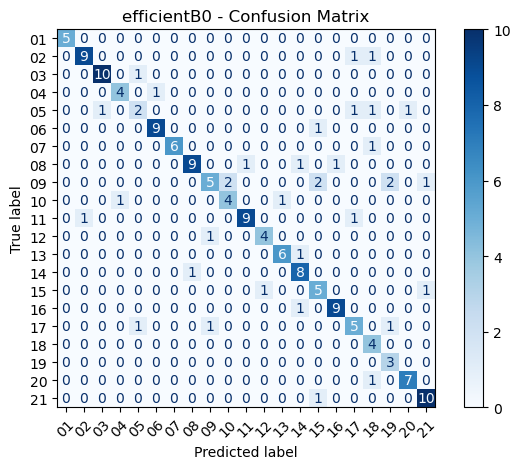

In [ ]:
best_val_loss = float('inf')
no_improve = 0
max_epochs = 30
patience = 6

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    
    model.eval()
    val_loss = 0
    metric_acc.reset()
    metric_precision.reset()
    metric_recall.reset()
    metric_f1.reset()

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            metric_acc.update(preds, labels)
            metric_precision.update(preds, labels)
            metric_recall.update(preds, labels)
            metric_f1.update(preds, labels)

    val_loss /= len(val_loader)
    val_acc = metric_acc.compute()
    val_prec = metric_precision.compute()
    val_rec = metric_recall.compute()
    val_f1 = metric_f1.compute()
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f}")

    # Save the best training model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc.item()
        best_val_f1 = val_f1.item()
        no_improve = 0
        torch.save(model.state_dict(), "80_classification_efficientnet.pth")
        print("Best model saved!")
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered!")
            break


# loading the model
model.load_state_dict(torch.load("80_classification_efficientnet.pth"))
model.eval()

# collect prediction
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Building confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# visible confusion matrix
print(f"\nBest Val Accuracy: {best_val_acc * 100:.2f}%")
print(f"Final F1-score: {best_val_f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
plt.title("efficientB0 - Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


C:\Users\23771\AppData\Local\Temp\ipykernel_27936\2892407370.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("80_classification_efficien

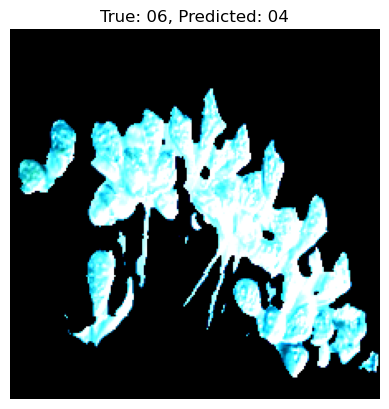

True class: 06 | Predicted class: 04


In [ ]:
import random
#Testing model
# Loading the saved model
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=len(class_names)).to(device)

model.load_state_dict(torch.load("80_classification_efficientnet.pth", map_location=device))
model.eval()

# Test a random image from test sets
images, labels = next(iter(test_loader))
idx = random.randint(0, len(images) - 1)
image = images[idx].to(device).unsqueeze(0)  # [1, 3, H, W]
true_label = labels[idx].item()

with torch.no_grad():
    output = model(image)
    pred = torch.argmax(output, dim=1).item()


# shoe the prediction result
plt.imshow(images[idx].permute(1, 2, 0))
plt.title(f"True: {class_names[true_label]}, Predicted: {class_names[pred]}")
plt.axis('off')
plt.show()

print(f"True class: {class_names[true_label]} | Predicted class: {class_names[pred]}")
